In [2]:
import pandas as pd
pumpkins = pd.read_csv("../data/US-pumpkins.csv")

#Filter the data to include only rows that use price per bushel
pumpkins = pumpkins[pumpkins['Package'].str.contains('bushel', case=True, regex=True)]
#return the first 5 rows of the filtered data
pumpkins.head()

,City Name,Type,Package,Variety,Sub Variety,Grade,Date,Low Price,High Price,Mostly Low,...,Unit of Sale,Quality,Condition,Appearance,Storage,Crop,Repack,Trans Mode,Unnamed: 24,Unnamed: 25
70,BALTIMORE,NaN,1 1/9 bushel cartons,PIE TYPE,NaN,NaN,9/24/16,15.0,15.0,15.0,...,NaN,NaN,NaN,NaN,NaN,NaN,N,NaN,NaN,NaN
71,BALTIMORE,NaN,1 1/9 bushel cartons,PIE TYPE,NaN,NaN,9/24/16,18.0,18.0,18.0,...,NaN,NaN,NaN,NaN,NaN,NaN,N,NaN,NaN,NaN
72,BALTIMORE,NaN,1 1/9 bushel cartons,PIE TYPE,NaN,NaN,10/1/16,18.0,18.0,18.0,...,NaN,NaN,NaN,NaN,NaN,NaN,N,NaN,NaN,NaN
73,BALTIMORE,NaN,1 1/9 bushel cartons,PIE TYPE,NaN,NaN,10/1/16,17.0,17.0,17.0,...,NaN,NaN,NaN,NaN,NaN,NaN,N,NaN,NaN,NaN
74,BALTIMORE,NaN,1 1/9 bushel cartons,PIE TYPE,NaN,NaN,10/8/16,15.0,15.0,15.0,...,NaN,NaN,NaN,NaN,NaN,NaN,N,NaN,NaN,NaN


In [3]:
#count how many cells are empty in each column
pumpkins.isnull().sum()

City Name            0
Type               406
Package              0
Variety              0
Sub Variety        167
Grade              415
Date                 0
Low Price            0
High Price           0
Mostly Low          24
Mostly High         24
Origin               0
Origin District    396
Item Size          114
Color              145
Environment        415
Unit of Sale       404
Quality            415
Condition          415
Appearance         415
Storage            415
Crop               415
Repack               0
Trans Mode         415
Unnamed: 24        415
Unnamed: 25        391
dtype: int64

In [4]:
#define columns to keep
new_columns = ['Package', 'Month', 'Low Price', 'High Price', 'Date']

#drop all other columns
pumpkins = pumpkins.drop(columns=[col for col in pumpkins.columns if col not in new_columns], axis=1)

Alternatively:

To make your dataframe easier to work with, select only the columns you need, using the loc function which extracts from the original dataframe a group of rows (passed as first parameter) and columns (passed as second parameter). The expression : in the case below means "all rows".


columns_to_select = ['Package', 'Low Price', 'High Price', 'Date']
pumpkins = pumpkins.loc[:, columns_to_select]



In [5]:
#calculate the average price from the high and low price columns
price = (pumpkins['Low Price'] + pumpkins['High Price']) / 2

#Get the month from the date column 
month = pd.DatetimeIndex(pumpkins['Date']).month

#Create a new dataframe with the month and price columns
new_pumpkins = pd.DataFrame({'Month': month, 'Package':pumpkins['Package'], 'Low Price': pumpkins['Low Price'], 'High Price': pumpkins['High Price'], 'Price': price})

In [6]:
# Convert the price of all cells prices by 1 1/9 bushels by dividing the price by 1 1/19
new_pumpkins.loc[new_pumpkins['Package'].str.contains('1 1/9'), 'Price'] = price/(1 + 1/9)

# Convert the price of all cells prices by 1/2 bushels by dividing the price by 1/2
new_pumpkins.loc[new_pumpkins['Package'].str.contains('1/2'), 'Price'] = price/(1/2)

In [ ]:
# return the first 5 rows of the data frame
new_pumpkins.head()

,Month,Package,Low Price,High Price,Price
70,9,1 1/9 bushel cartons,15.0,15.0,13.5
71,9,1 1/9 bushel cartons,18.0,18.0,16.2
72,10,1 1/9 bushel cartons,18.0,18.0,16.2
73,10,1 1/9 bushel cartons,17.0,17.0,15.3
74,10,1 1/9 bushel cartons,15.0,15.0,13.5


In [8]:
new_pumpkins.tail()

,Month,Package,Low Price,High Price,Price
1738,9,1/2 bushel cartons,15.00,15.0,30.00
1739,9,1/2 bushel cartons,13.75,15.0,28.75
1740,9,1/2 bushel cartons,10.75,15.0,25.75
1741,9,1/2 bushel cartons,12.00,12.0,24.00
1742,9,1/2 bushel cartons,12.00,12.0,24.00


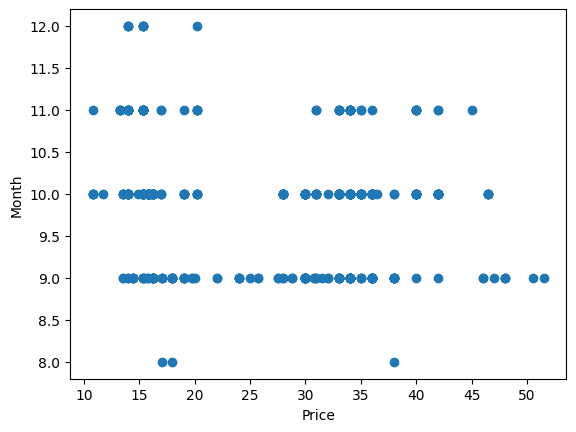

In [ ]:
import matplotlib.pyplot as plt

# values we want to plot
price = new_pumpkins.Price
month = new_pumpkins.Month

plt.scatter(price, month)
plt.xlabel('Price')
plt.ylabel('Month')
plt.show()

Text(0, 0.5, 'Average Pumpkin Price')

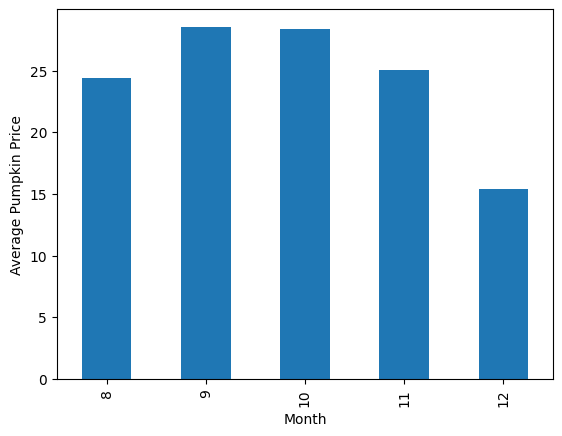

In [ ]:
# using pandas (dataframe) to plot the data
new_pumpkins.groupby('Month')['Price'].mean().plot(kind='bar')
plt.xlabel('Month')
plt.ylabel('Average Pumpkin Price') 

Given the graph, the cheapest month to buy a pumpkin in the US is December

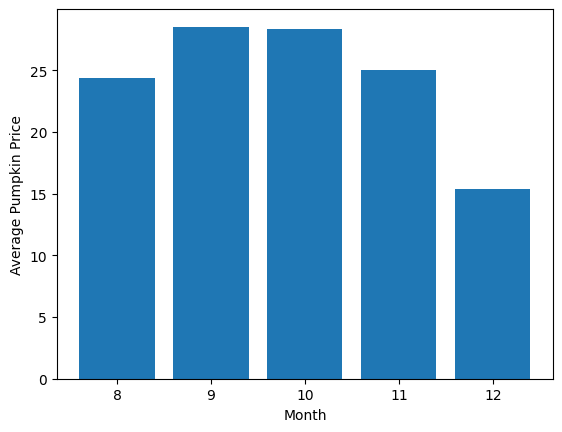

In [ ]:
# using matplotlib to plot the data that we grouped by month and took the average price
plt.bar(new_pumpkins.groupby('Month')['Price'].mean().index, new_pumpkins.groupby('Month')['Price'].mean().values)
# notice the index and values attributes to get the x and y values for the bar plot
plt.xlabel('Month')
plt.ylabel('Average Pumpkin Price')
plt.show()